# 2. 函数拟合 - 两层ReLU神经网络

理论和实验证明，一个两层的ReLU网络可以模拟任何函数。本Notebook实现基于TensorFlow的函数拟合。

任务：自定义函数，采样训练/测试集，构建模型，训练并验证。

In [35]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
import matplotlib.pyplot as plt

# 固定随机种子，保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# # 打印软件版本，方便调试
# print('numpy', np.__version__)
# print('tensorflow', tf.__version__)
# print('matplotlib', matplotlib.__version__)

## 2.1 函数定义与采样

目标函数：f(x)=sin(2*pi*x)+0.3*cos(5*pi*x)

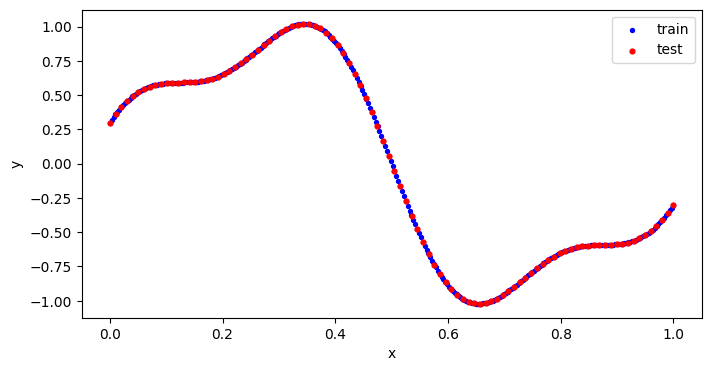

In [36]:
# 定义目标函数（真实函数，用于拟合目标）
def target_fun(x):
    # y = sin(2*pi*x) + 0.3*cos(5*pi*x)
    # 具有多重频率分量，适合测试网络拟合能力
    return np.sin(2*np.pi*x) + 0.3*np.cos(5*np.pi*x)

# 生成训练集和测试集数据，x 输入在 [0,1] 区间
# 训练集 300 个点，测试集 100 个点，方便快速训练测试
x_train = np.linspace(0,1,300).reshape(-1,1).astype(np.float32)
y_train = target_fun(x_train).astype(np.float32)
x_test = np.linspace(0,1,100).reshape(-1,1).astype(np.float32)
y_test = target_fun(x_test).astype(np.float32)

# 可视化采样点
gplt = plt.figure(figsize=(8,4))
plt.scatter(x_train, y_train, c='blue', s=8, label='train')
plt.scatter(x_test, y_test, c='red', s=12, label='test')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 2.2 构建两层ReLU网络（手工实现）

In [37]:
# 定义两层ReLU网络
# 隐层节点 64+64，输出 1 个标量，适合拟合连续函数
class ReLUNet(tf.Module):
    def __init__(self):
        super().__init__()
        # 第一层参数：1->64
        self.W1 = tf.Variable(tf.random.normal([1,64], stddev=0.1), name='W1')
        self.b1 = tf.Variable(tf.zeros([64]), name='b1')
        # 第二层参数：64->64
        self.W2 = tf.Variable(tf.random.normal([64,64], stddev=0.1), name='W2')
        self.b2 = tf.Variable(tf.zeros([64]), name='b2')
        # 第三层参数：64->1
        self.W3 = tf.Variable(tf.random.normal([64,1], stddev=0.1), name='W3')
        self.b3 = tf.Variable(tf.zeros([1]), name='b3')

    def __call__(self, x):
        # 前向传播：两层ReLU + 线性输出
        h1 = tf.nn.relu(tf.matmul(x, self.W1) + self.b1)
        h2 = tf.nn.relu(tf.matmul(h1, self.W2) + self.b2)
        out = tf.matmul(h2, self.W3) + self.b3
        return out

# 实例化模型与优化器
model = ReLUNet()
optimizer = tf.optimizers.Adam(learning_rate=1e-3)

@tf.function
def loss_fn(x, y):
    pred = model(x)
    # 均方误差损失
    return tf.reduce_mean(tf.square(pred - y))

@tf.function
def train_step(x, y):
    # 自动求导训练一步
    with tf.GradientTape() as tape:
        loss = loss_fn(x, y)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

## 2.3 模型训练

In [ ]:
# 使用小批量训练+学习率衰减，效果更稳定
batch_size = 64
dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
# 数据随机打乱、重复、分批
dataset = dataset.shuffle(buffer_size=300, seed=42).batch(batch_size)

epochs = 5000
history = []
# 学习率调度：从 1e-3 退火到 1e-4
scheduler = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=500,
    decay_rate=0.97,
    staircase=False)
optimizer.learning_rate = scheduler

for epoch in range(epochs):
    epoch_loss = 0.0
    batch_count = 0
    for xb, yb in dataset:
        loss_v = train_step(xb, yb)
        epoch_loss += loss_v.numpy()
        batch_count += 1
    epoch_loss /= batch_count
    history.append(epoch_loss)
    if (epoch + 1) % 250 == 0:
        print('Epoch', epoch + 1, 'loss', epoch_loss)

# 训练损失曲线展示
plt.figure(figsize=(6,4))
plt.plot(history, label='train loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.grid(True)
plt.show()

## 2.4 评估与结果展示

Test MSE 0.0017364692


Text(0, 0.5, 'y')

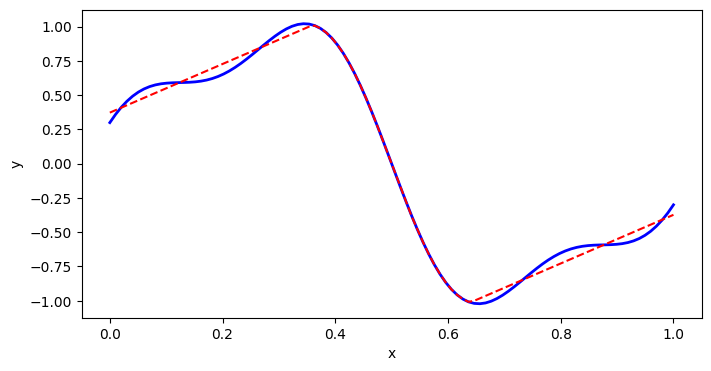

In [39]:
# 测试集评估
y_pred = model(x_test).numpy()
mse_test = np.mean((y_pred - y_test)**2)
print('Test MSE', mse_test)

# 绘制拟合结果
plt.figure(figsize=(8,4))
plt.plot(x_test, y_test, label='ground truth', color='blue', linewidth=2)
plt.plot(x_test, y_pred, label='prediction', color='red', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')

## 2.5 NumPy 手工实现两层 ReLU 网络（附加加分）

NumPy Epoch 400 loss 0.4661187025155721
NumPy Epoch 800 loss 0.4281004078929911
NumPy Epoch 1200 loss 0.36337339449684103
NumPy Epoch 1600 loss 0.2905543287756606
NumPy Epoch 2000 loss 0.22738839976186695
NumPy Epoch 2400 loss 0.18297913649477518
NumPy Epoch 2800 loss 0.1654664729573438
NumPy Epoch 3200 loss 0.1557828347698555
NumPy Epoch 3600 loss 0.14824658753661077
NumPy Epoch 4000 loss 0.147326453420286


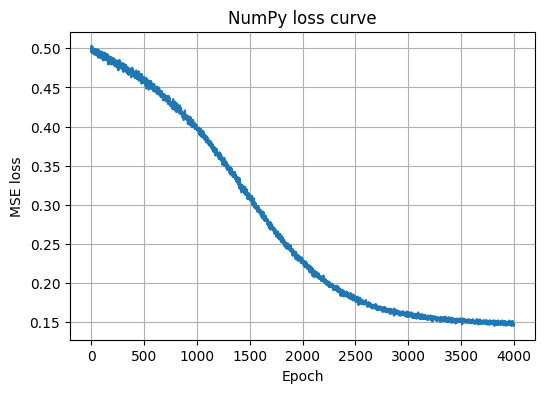

NumPy Test MSE 0.14936108804087403


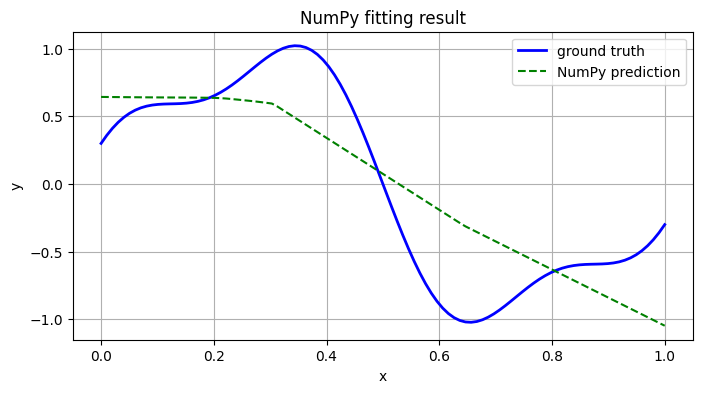

In [42]:
# NumPy 实现，两层 ReLU，全量 + mini-batch
import numpy as np

# 复用 x_train / y_train / x_test / y_test
x_train_np = x_train.copy(); y_train_np = y_train.copy()
x_test_np = x_test.copy(); y_test_np = y_test.copy()

np.random.seed(42)
W1 = np.random.randn(1, 64) * 0.1; b1 = np.zeros((1,64))
W2 = np.random.randn(64,64) * 0.1; b2 = np.zeros((1,64))
W3 = np.random.randn(64,1) * 0.1; b3 = np.zeros((1,1))

lr = 5e-4
epochs_np = 4000
batch_size_np = 64
n = x_train_np.shape[0]

history_np = []

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(np.float32)

for epoch in range(epochs_np):
    idx = np.random.permutation(n)
    x_shuffled = x_train_np[idx]; y_shuffled = y_train_np[idx]
    batch_loss = 0.0

    for i in range(0, n, batch_size_np):
        xb = x_shuffled[i:i+batch_size_np]; yb = y_shuffled[i:i+batch_size_np]

        z1 = xb.dot(W1) + b1
        a1 = relu(z1)
        z2 = a1.dot(W2) + b2
        a2 = relu(z2)
        yp = a2.dot(W3) + b3

        loss_np = np.mean((yp - yb)**2)
        batch_loss += loss_np

        m_b = xb.shape[0]
        dy = 2*(yp - yb)/m_b

        dW3 = a2.T.dot(dy); db3 = np.sum(dy, axis=0, keepdims=True)
        da2 = dy.dot(W3.T)
        dz2 = da2 * relu_grad(z2)
        dW2 = a1.T.dot(dz2); db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2.dot(W2.T)
        dz1 = da1 * relu_grad(z1)
        dW1 = xb.T.dot(dz1); db1 = np.sum(dz1, axis=0, keepdims=True)

        # L2 正则化
        l2 = 1e-4
        dW1 += 2*l2*W1; dW2 += 2*l2*W2; dW3 += 2*l2*W3

        W3 -= lr * dW3; b3 -= lr * db3
        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1

    history_np.append(batch_loss / (n // batch_size_np + 1))

    if (epoch + 1) % 400 == 0:
        print('NumPy Epoch', epoch + 1, 'loss', history_np[-1])

plt.figure(figsize=(6,4))
plt.plot(history_np)
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('NumPy loss curve')
plt.grid(True)
plt.show()

# NumPy 测试
y_pred_np = relu(relu(x_test_np.dot(W1)+b1).dot(W2)+b2).dot(W3)+b3
mse_test_np = np.mean((y_pred_np - y_test_np)**2)
print('NumPy Test MSE', mse_test_np)

plt.figure(figsize=(8,4))
plt.plot(x_test_np, y_test_np, label='ground truth', color='blue', linewidth=2)
plt.plot(x_test_np, y_pred_np, label='NumPy prediction', color='green', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.title('NumPy fitting result')
plt.legend()
plt.grid(True)
plt.show()